In [21]:
from pathlib import Path
import pickle
import numpy as np
import gvar as gv

import matplotlib.pyplot as plt
%matplotlib inline

from measurements import *
from flowing import flowtime_to_radius

In [18]:
from ensemble_data import data_16_x_64_1p5Tc as ense_data

ns = ense_data['ns']
nt = ense_data['nt']

flowtimes = ense_data['flowtimes']

In [3]:
data_path = Path.cwd() / 'data'

skip_configs = 55

flowmeas_config : list[FlowMeasurements] = pickle.load((data_path / 'data0a.pkl').open('rb'))[skip_configs:]

ense_all = np.load(data_path / 'data0.npy')[skip_configs:]
print(ense_all.shape)

print('number of configs =', len(flowmeas_config))

(4000, 22, 9, 1914)
number of configs = 4000


In [19]:
# all improved topological charges (first index is config, second is flowtime)

n_configs   = len(flowmeas_config)
n_flowtimes = len(flowtimes)

icharge_config_flow = np.array(
    [ [meas.icharge for meas in flowmeas]
      for flowmeas in flowmeas_config ],
    dtype=float
)
print(icharge_config_flow.shape, icharge_config_flow.dtype)

(4000, 22) float64


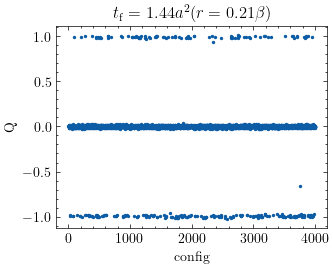

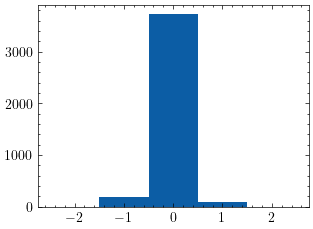

In [24]:
# plotting topological charge for each configuration

iflow = -1

plt.scatter(
    x = range(n_configs),
    y = icharge_config_flow[:, iflow],
    s = 2,
    # label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('Q')
# plt.legend()
plt.title(rf'$t_\mathrm{{f}} = {flowtimes[iflow]:.2f} a^2 (r = {flowtime_to_radius(flowtimes[iflow], nt):.2f} \beta)$')
plt.show()
plt.close()


plt.hist(
    x = icharge_config_flow[:, iflow],
    bins = (-2.5, -1.5, -0.5, 0.5, 1.5, 2.5)
)
plt.show()

0.03 0.05 0.08 0.11 0.14 0.17 0.21 0.25 0.28 0.32 0.37 0.42 0.47 0.53 0.59 0.66 0.73 0.83 0.94 1.07 1.23 1.44
2.4636 pm 0.05597,  1.4102 pm 0.03187,  0.7739 pm 0.01725,  0.4091 pm 0.00900,  0.2085 pm 0.00456,  0.1034 pm 0.00227,  0.0500 pm 0.00111,  0.0242 pm 0.00054,  0.0121 pm 0.00028,  0.0063 pm 0.00015,  0.0035 pm 0.00010,  0.0023 pm 0.00008,  0.0017 pm 0.00007,  0.0014 pm 0.00006,  0.0012 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006,  0.0011 pm 0.00006
1.25 pm 0.007,  1.09 pm 0.006,  0.94 pm 0.005,  0.80 pm 0.004,  0.68 pm 0.004,  0.57 pm 0.003,  0.47 pm 0.003,  0.39 pm 0.002,  0.33 pm 0.002,  0.28 pm 0.002,  0.24 pm 0.002,  0.22 pm 0.002,  0.20 pm 0.002,  0.19 pm 0.002,  0.19 pm 0.002,  0.18 pm 0.002,  0.18 pm 0.003,  0.18 pm 0.003,  0.18 pm 0.003,  0.18 pm 0.003,  0.18 pm 0.003,  0.18 pm 0.003


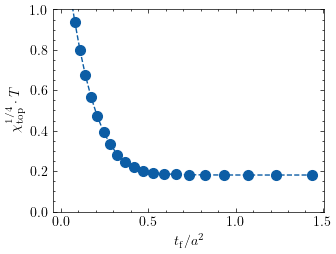

In [36]:
# topological susceptibility as function of flowtime

top_sus = np.mean(icharge_config_flow**2, axis=0) / (ns/nt)**3
top_sus_4 = top_sus ** (1/4)

top_sus_std = np.std(icharge_config_flow**2, axis=0, ddof=1) / np.sqrt(n_configs) / (ns/nt)**3
top_sus_4_std = top_sus_std / 4 / top_sus**(3/4)

plt.errorbar(
    x = flowtimes,
    y = top_sus_4,
    yerr=top_sus_4_std,
    marker = 'o',
    markersize = 7,
    ls='--'
)
print(*(f'{tf:.2f}' for tf in flowtimes))
print(',  '.join(f'{top:.4f} pm {dtop:.5f}' for top, dtop in zip(top_sus, top_sus_std)))
print(',  '.join(f'{top:.2f} pm {dtop:.3f}' for top, dtop in zip(top_sus_4, top_sus_4_std)))

plt.xlabel(rf'$t_\mathrm{{f}} / a^2$')
plt.ylabel(rf'$\chi_\mathrm{{top}}^{{1/4}} \cdot T$')

plt.ylim(0, 1)

plt.show()

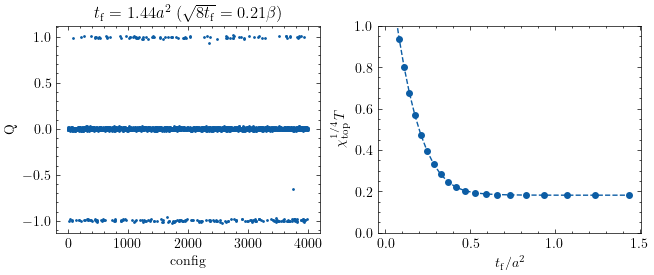

Saved: /home/luisneubauer/Desktop/codeundso/milc_luis/zeugs/plots/Q_and_chi_1x2.pdf


In [27]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')
plt.rcParams.update({'font.size': 10})

latex_width_pts = 469.75502
wlatex = 6.5243753  # inches

iflow = -1

# data
Q = icharge_config_flow[:, iflow]
top_sus = np.mean(icharge_config_flow**2, axis=0) / (ns/nt)**3
top_sus_4 = top_sus ** (1/4)

# figure size: width = LaTeX width, height chosen to look good
fig, (ax0, ax1) = plt.subplots(
    1, 2,
    figsize=(wlatex, 0.42 * wlatex),
    constrained_layout=True
)

# Left: Q vs config
ax0.scatter(
    range(n_configs),
    Q,
    s=1
)
ax0.set_xlabel('config')
ax0.set_ylabel('Q')
ax0.set_title(
    rf'$t_\mathrm{{f}} = {flowtimes[iflow]:.2f} a^2$'
    rf' $(\sqrt{{8 t_\mathrm{{f}}}} = {flowtime_to_radius(flowtimes[iflow], nt):.2f} \beta$)'
)

# Right: chi^(1/4) * T vs flowtime
ax1.errorbar(
    flowtimes,
    top_sus_4,
    marker='o',
    markersize=4,
    ls='--'
)
ax1.set_xlabel(r'$t_\mathrm{f} / a^2$')
ax1.set_ylabel(r'$\chi_\mathrm{top}^{1/4}\,T$')
ax1.set_ylim(0, 1)

# save
out = Path.cwd() / 'plots' / 'Q_and_chi_1x2.pdf'
fig.savefig(out, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Saved: {out}")


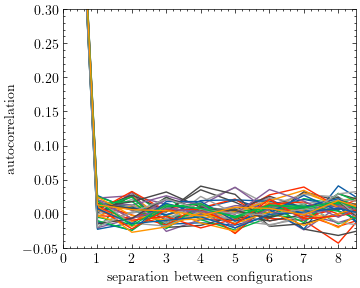

Saved: /home/luisneubauer/Desktop/codeundso/milc_luis/zeugs/plots/autocorrelations.pdf


In [25]:
from matplotlib.ticker import MultipleLocator

# check autocorrelation
skip = 55
taus   = [4, 6, 8]
iflows = [11, 16, 21]
irs    = [0, 5, 15, 30, 45]

w = 0.55 * wlatex
h = 0.8 * w
fig, ax = plt.subplots(
    figsize=(w, h),
    constrained_layout=True
)

for iflow in iflows:
    for tau in taus:
        for ir in irs:
            autocorrs = gv.dataset.autocorr(
                ense_all[skip:, iflow, tau, ir]
            )
            ax.plot(
                autocorrs[:17],
                lw=1
            )

ax.set_xlim(0, 8.5)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylim(-0.05, 0.3)
ax.set_xlabel('separation between configurations')
ax.set_ylabel('autocorrelation')

out = Path.cwd() / 'plots' / 'autocorrelations.pdf'
fig.savefig(out, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Saved: {out}")

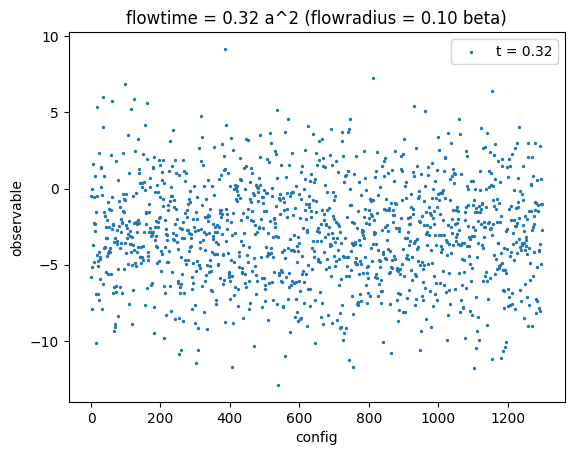

In [10]:
# thermalization

iflow = 9
config_max = 1300

obs = ense_all[:, iflow, 5, 2]

plt.scatter(
    x = range(config_max),
    y = obs[:config_max],
    s = 2,
    label = f't = {flowtimes[iflow]:.2f}'
)
plt.xlabel('config')
plt.ylabel('observable')
plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2 (flowradius = {flowtime_to_radius(flowtimes[iflow], nt):.2f} beta)')
plt.show()

/tmp/ipykernel_137351/3837609552.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


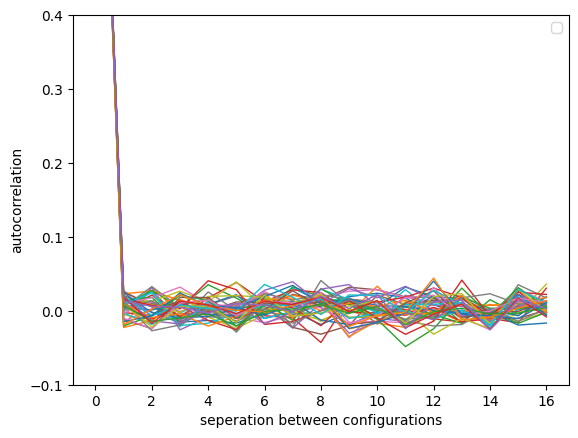

In [11]:
# check autocorrelation

skip = 55

taus   = [4,6,8]
iflows = [11, 16, 21]
irs    = [0, 5, 15, 30, 45]

for iflow in iflows:
    for tau in taus:
        for ir in irs:
            autocorrs = gv.dataset.autocorr(ense_all[skip:, iflow, tau, ir])
            plt.plot(
                autocorrs[:17],
                lw = 1,
                # label = f'ifl={ifl}'
            )
            plt.legend()

plt.ylim(-0.1, 0.4)
plt.xlabel('seperation between configurations')
plt.ylabel('autocorrelation')
# plt.title('autocorrelation of wide range of flowtimes, time and spatial separations')
plt.show()